# GuppyLM Email Summarizer Training

Train a small vanilla transformer from scratch on our Enron email-summary ChatML dataset.

This notebook is built for Google Colab GPU sessions launched from VS Code. It uses the project artifacts produced by the dashboard:

- `data/training/train.jsonl`
- `data/training/eval.jsonl`
- `data/training/test.jsonl`
- `data/training/tokenizer.json`

Project defaults: `vocab_size=4096`, `max_seq_len=512`, assistant-only training loss.

## 1. Install Dependencies

Run this once per Colab runtime. The notebook avoids HuggingFace Transformers; it uses vanilla PyTorch plus `tokenizers`.

In [1]:
!pip install -q torch tokenizers tqdm numpy matplotlib

import json
import math
import os
import random
import shutil
import tarfile
import time
from dataclasses import asdict, dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tokenizers import Tokenizer
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [2]:
!nvidia-smi

Sun May 17 14:43:11 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8             14W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

## 2. Runtime Paths

If this notebook is running inside the repository, it will use local `data/training`. If running in a fresh Colab runtime, upload `training.zip` containing the `data/training/` folder.

In [19]:
WORK_DIR = Path.cwd()
DATA_DIR = WORK_DIR / "data" / "training"
CHECKPOINT_DIR = WORK_DIR / "checkpoints"
EVAL_DIR = WORK_DIR / "evaluation"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

required = ["train.jsonl", "eval.jsonl", "test.jsonl", "tokenizer.json"]

# If Colab starts in /content, use /content as the stable workspace.
if not DATA_DIR.exists() and Path("/content").exists():
    WORK_DIR = Path("/content")
    DATA_DIR = WORK_DIR / "data" / "training"
    CHECKPOINT_DIR = WORK_DIR / "checkpoints"
    EVAL_DIR = WORK_DIR / "evaluation"
    CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
    EVAL_DIR.mkdir(parents=True, exist_ok=True)

missing = [name for name in required if not (DATA_DIR / name).exists()]

if missing:
    print("Missing training files:", missing)
    print("Looking for training.zip in common Colab locations...")

    zip_candidates = [
        WORK_DIR / "training.zip",
        Path("/content/training.zip"),
        Path("/content/drive/MyDrive/training.zip"),
    ]
    zip_path = next((path for path in zip_candidates if path.exists()), None)

    if zip_path is None:
        raise FileNotFoundError(
            "Upload training.zip to Colab first, then rerun this cell. "
            "Best option for VS Code Colab: upload it to the Colab file panel as /content/training.zip. "
            "Alternative: put it in Google Drive at MyDrive/training.zip."
        )

    print(f"Found {zip_path}. Extracting to {WORK_DIR}...")
    shutil.unpack_archive(str(zip_path), str(WORK_DIR))

missing = [name for name in required if not (DATA_DIR / name).exists()]
if missing:
    raise FileNotFoundError(
        f"Still missing files after extracting zip: {missing}. "
        "The zip must contain data/training/train.jsonl, eval.jsonl, test.jsonl, and tokenizer.json."
    )

print(f"Working directory: {WORK_DIR}")
for name in required:
    path = DATA_DIR / name
    if path.suffix == ".jsonl":
        rows = sum(1 for _ in path.open(encoding="utf-8"))
        print(f"{path}: {rows:,} rows")
    else:
        print(f"{path}: {path.stat().st_size / 1024:.1f} KiB")

Working directory: /content
/content/data/training/train.jsonl: 33,632 rows
/content/data/training/eval.jsonl: 3,956 rows
/content/data/training/test.jsonl: 1,978 rows
/content/data/training/tokenizer.json: 259.2 KiB


In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
from pathlib import Path

print(Path("/content/drive").exists())
print(Path("/content/drive/MyDrive").exists())
print(Path("/content/drive/MyDrive/training.zip").exists())

True
True
True


In [16]:
import shutil
from pathlib import Path

zip_path = Path("/content/drive/MyDrive/training.zip")
WORK_DIR = Path("/content")

print(zip_path.exists(), zip_path.stat().st_size / 1024 / 1024, "MiB")
shutil.unpack_archive(str(zip_path), str(WORK_DIR))

print(Path("/content/data/training/train.jsonl").exists())
print(Path("/content/data/training/eval.jsonl").exists())
print(Path("/content/data/training/test.jsonl").exists())
print(Path("/content/data/training/tokenizer.json").exists())

True 14.882131576538086 MiB
False
False
False
False


In [18]:
from pathlib import Path
import shutil

src = Path("/content")
dst = Path("/content/data/training")
dst.mkdir(parents=True, exist_ok=True)

for name in ["train.jsonl", "eval.jsonl", "test.jsonl", "tokenizer.json", "tokenizer_metrics.json", "val.jsonl"]:
    source = src / name
    if source.exists():
        shutil.copy2(source, dst / name)
        print("copied", source, "->", dst / name)
    else:
        print("missing", source)
for name in ["train.jsonl", "eval.jsonl", "test.jsonl", "tokenizer.json"]:
    print(name, (dst / name).exists())

copied /content/train.jsonl -> /content/data/training/train.jsonl
copied /content/eval.jsonl -> /content/data/training/eval.jsonl
copied /content/test.jsonl -> /content/data/training/test.jsonl
copied /content/tokenizer.json -> /content/data/training/tokenizer.json
copied /content/tokenizer_metrics.json -> /content/data/training/tokenizer_metrics.json
copied /content/val.jsonl -> /content/data/training/val.jsonl
train.jsonl True
eval.jsonl True
test.jsonl True
tokenizer.json True


## 3. Configuration

These values must match the tokenizer artifacts created by the dashboard. We use `max_seq_len=512` because email inputs are much longer than the original GuppyLM fish-chat examples.

In [20]:
@dataclass
class GuppyConfig:
    vocab_size: int = 4096
    max_seq_len: int = 512
    d_model: int = 384
    n_layers: int = 6
    n_heads: int = 6
    ffn_hidden: int = 768
    dropout: float = 0.1
    pad_id: int = 0
    bos_id: int = 1
    eos_id: int = 2


@dataclass
class TrainConfig:
    batch_size: int = 16
    grad_accum_steps: int = 2
    learning_rate: float = 3e-4
    min_lr: float = 3e-5
    weight_decay: float = 0.1
    warmup_steps: int = 200
    max_steps: int = 6000
    eval_interval: int = 250
    eval_batches: int = 80
    grad_clip: float = 1.0
    seed: int = 42
    num_workers: int = 2


model_config = GuppyConfig()
train_config = TrainConfig()

torch.manual_seed(train_config.seed)
random.seed(train_config.seed)
np.random.seed(train_config.seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
print(model_config)
print(train_config)

cuda
GuppyConfig(vocab_size=4096, max_seq_len=512, d_model=384, n_layers=6, n_heads=6, ffn_hidden=768, dropout=0.1, pad_id=0, bos_id=1, eos_id=2)
TrainConfig(batch_size=16, grad_accum_steps=2, learning_rate=0.0003, min_lr=3e-05, weight_decay=0.1, warmup_steps=200, max_steps=6000, eval_interval=250, eval_batches=80, grad_clip=1.0, seed=42, num_workers=2)


## 4. Validate Tokenizer and Data

This checks vocab size, special token IDs, ChatML markers, and max encoded length before training.

In [21]:
tokenizer = Tokenizer.from_file(str(DATA_DIR / "tokenizer.json"))
print("vocab size:", tokenizer.get_vocab_size())
print("special token ids:", {s: tokenizer.token_to_id(s) for s in ["<pad>", "<|im_start|>", "<|im_end|>"]})
assert tokenizer.get_vocab_size() == model_config.vocab_size
assert tokenizer.token_to_id("<pad>") == model_config.pad_id
assert tokenizer.token_to_id("<|im_start|>") == model_config.bos_id
assert tokenizer.token_to_id("<|im_end|>") == model_config.eos_id

for split in ["train", "eval", "test"]:
    path = DATA_DIR / f"{split}.jsonl"
    rows = 0
    missing_markers = 0
    max_len = 0
    truncated = 0
    with path.open(encoding="utf-8") as f:
        for line in f:
            row = json.loads(line)
            text = row["text"]
            rows += 1
            missing_markers += int("<|im_start|>user" not in text or "<|im_start|>assistant" not in text or "<|im_end|>" not in text)
            max_len = max(max_len, len(tokenizer.encode(text).ids))
            truncated += int(bool(row.get("truncated")))
    print(f"{split}: rows={rows:,}, max_len={max_len}, truncated={truncated:,}, missing_markers={missing_markers}")
    assert max_len <= model_config.max_seq_len
    assert missing_markers == 0

vocab size: 4096
special token ids: {'<pad>': 0, '<|im_start|>': 1, '<|im_end|>': 2}
train: rows=33,632, max_len=512, truncated=8,929, missing_markers=0
eval: rows=3,956, max_len=512, truncated=1,035, missing_markers=0
test: rows=1,978, max_len=512, truncated=504, missing_markers=0


## 5. Dataset With Assistant-Only Loss

The model receives the full email prompt and summary, but the loss ignores the user/email prompt tokens. This trains the model to generate the assistant summary instead of spending capacity learning to reproduce the email.

In [22]:
ASSISTANT_MARKER = "<|im_start|>assistant\n"

class EmailSummaryDataset(Dataset):
    def __init__(self, path, tokenizer, max_len=512):
        self.path = Path(path)
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.samples = []
        skipped = 0

        with self.path.open(encoding="utf-8") as f:
            for line in f:
                row = json.loads(line)
                text = row.get("text", "")
                if ASSISTANT_MARKER not in text:
                    skipped += 1
                    continue

                ids = tokenizer.encode(text).ids[:max_len]
                prefix = text.split(ASSISTANT_MARKER, 1)[0] + ASSISTANT_MARKER
                prefix_len = len(tokenizer.encode(prefix).ids)

                labels = ids.copy()
                labels[:min(prefix_len, len(labels))] = [-100] * min(prefix_len, len(labels))
                if len(ids) < 2 or all(value == -100 for value in labels[1:]):
                    skipped += 1
                    continue

                self.samples.append((ids, labels))

        print(f"{self.path.name}: loaded {len(self.samples):,}, skipped {skipped:,}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids, labels = self.samples[idx]
        return torch.tensor(ids[:-1], dtype=torch.long), torch.tensor(labels[1:], dtype=torch.long)


def collate_batch(batch, pad_id=0):
    xs, ys = zip(*batch)
    max_len = max(x.numel() for x in xs)
    x_pad = torch.full((len(xs), max_len), pad_id, dtype=torch.long)
    y_pad = torch.full((len(ys), max_len), -100, dtype=torch.long)
    for i, (x, y) in enumerate(zip(xs, ys)):
        x_pad[i, :x.numel()] = x
        y_pad[i, :y.numel()] = y
    return x_pad, y_pad


train_ds = EmailSummaryDataset(DATA_DIR / "train.jsonl", tokenizer, model_config.max_seq_len)
eval_ds = EmailSummaryDataset(DATA_DIR / "eval.jsonl", tokenizer, model_config.max_seq_len)
test_ds = EmailSummaryDataset(DATA_DIR / "test.jsonl", tokenizer, model_config.max_seq_len)

train_loader = DataLoader(
    train_ds,
    batch_size=train_config.batch_size,
    shuffle=True,
    collate_fn=lambda b: collate_batch(b, model_config.pad_id),
    num_workers=train_config.num_workers,
    pin_memory=torch.cuda.is_available(),
)
eval_loader = DataLoader(
    eval_ds,
    batch_size=train_config.batch_size,
    shuffle=False,
    collate_fn=lambda b: collate_batch(b, model_config.pad_id),
    num_workers=train_config.num_workers,
    pin_memory=torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size=train_config.batch_size,
    shuffle=False,
    collate_fn=lambda b: collate_batch(b, model_config.pad_id),
    num_workers=train_config.num_workers,
    pin_memory=torch.cuda.is_available(),
)

train.jsonl: loaded 33,632, skipped 0
eval.jsonl: loaded 3,956, skipped 0
test.jsonl: loaded 1,978, skipped 0


## 6. Model

A small vanilla decoder-only transformer: learned positions, causal self-attention, ReLU FFN, LayerNorm, tied token embeddings.

In [23]:
class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.d_model % config.n_heads == 0
        self.n_heads = config.n_heads
        self.head_dim = config.d_model // config.n_heads
        self.qkv = nn.Linear(config.d_model, 3 * config.d_model)
        self.out = nn.Linear(config.d_model, config.d_model)
        self.dropout = nn.Dropout(config.dropout)

    def forward(self, x):
        b, t, c = x.shape
        qkv = self.qkv(x).view(b, t, 3, self.n_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        y = F.scaled_dot_product_attention(
            q, k, v,
            attn_mask=None,
            dropout_p=self.dropout.p if self.training else 0.0,
            is_causal=True,
        )
        y = y.transpose(1, 2).contiguous().view(b, t, c)
        return self.out(y)


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(config.d_model, config.ffn_hidden),
            nn.ReLU(),
            nn.Linear(config.ffn_hidden, config.d_model),
            nn.Dropout(config.dropout),
        )

    def forward(self, x):
        return self.net(x)


class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1 = nn.LayerNorm(config.d_model)
        self.attn = CausalSelfAttention(config)
        self.ln2 = nn.LayerNorm(config.d_model)
        self.ffn = FeedForward(config)

    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.ffn(self.ln2(x))
        return x


class GuppyEmailLM(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.tok_emb = nn.Embedding(config.vocab_size, config.d_model)
        self.pos_emb = nn.Embedding(config.max_seq_len, config.d_model)
        self.drop = nn.Dropout(config.dropout)
        self.blocks = nn.ModuleList([Block(config) for _ in range(config.n_layers)])
        self.ln_f = nn.LayerNorm(config.d_model)
        self.lm_head = nn.Linear(config.d_model, config.vocab_size, bias=False)
        self.lm_head.weight = self.tok_emb.weight
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, labels=None):
        b, t = idx.shape
        if t > self.config.max_seq_len:
            raise ValueError(f"Sequence length {t} > max_seq_len {self.config.max_seq_len}")
        pos = torch.arange(t, device=idx.device)
        x = self.drop(self.tok_emb(idx) + self.pos_emb(pos))
        for block in self.blocks:
            x = block(x)
        logits = self.lm_head(self.ln_f(x))
        loss = None
        if labels is not None:
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), labels.reshape(-1), ignore_index=-100)
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=80, temperature=0.8, top_k=50):
        self.eval()
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.config.max_seq_len:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / max(temperature, 1e-6)
            if top_k:
                values, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < values[:, [-1]]] = -float("inf")
            probs = F.softmax(logits, dim=-1)
            next_id = torch.multinomial(probs, num_samples=1)
            idx = torch.cat([idx, next_id], dim=1)
            if next_id.item() == self.config.eos_id:
                break
        return idx

    def parameter_count(self):
        return sum(p.numel() for p in self.parameters())


model = GuppyEmailLM(model_config).to(device)
print(f"parameters: {model.parameter_count():,} ({model.parameter_count()/1e6:.2f}M)")

parameters: 8,873,472 (8.87M)


## 7. Baseline Before Training

This is the random-weight baseline required before training. It should have high loss/perplexity and incoherent generated samples.

In [24]:
@torch.no_grad()
def evaluate_loss(model, loader, max_batches=None):
    model.eval()
    losses = []
    for i, (x, y) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)
        _, loss = model(x, y)
        losses.append(loss.item())
    mean_loss = float(np.mean(losses)) if losses else float("inf")
    ppl = math.exp(min(mean_loss, 20))
    return mean_loss, ppl


def prompt_to_ids(email_text):
    prompt = f"<|im_start|>user\n{email_text}<|im_end|>\n<|im_start|>assistant\n"
    ids = tokenizer.encode(prompt).ids[-model_config.max_seq_len:]
    return torch.tensor([ids], dtype=torch.long, device=device), prompt


def summarize(model, email_text, max_new_tokens=80, temperature=0.8, top_k=50):
    ids, prompt = prompt_to_ids(email_text)
    out = model.generate(ids, max_new_tokens=max_new_tokens, temperature=temperature, top_k=top_k)
    text = tokenizer.decode(out[0].tolist(), skip_special_tokens=False)
    answer = text.split("<|im_start|>assistant\n")[-1]
    answer = answer.split("<|im_end|>")[0]
    return answer.strip()

baseline_loss, baseline_ppl = evaluate_loss(model, eval_loader, max_batches=train_config.eval_batches)
print(f"random baseline eval_loss={baseline_loss:.4f}, perplexity={baseline_ppl:.2f}")

sample_emails = [
    "The budget review meeting has moved to Friday at 2pm. Please bring final numbers and confirm attendance.",
    "Please send the signed contract by noon tomorrow. Legal needs it before the client call.",
    "Lunch menu for next week is attached. Reply if you have dietary restrictions.",
]

baseline_samples = []
for email in sample_emails:
    output = summarize(model, email, max_new_tokens=40)
    baseline_samples.append({"email": email, "output": output})
    print("EMAIL:", email)
    print("BASELINE:", output)
    print()

baseline_results = {
    "eval_loss": baseline_loss,
    "perplexity": baseline_ppl,
    "samples": baseline_samples,
    "note": "Random-weight baseline before training.",
}
(EVAL_DIR / "baseline_results.json").write_text(json.dumps(baseline_results, indent=2), encoding="utf-8")

random baseline eval_loss=8.4038, perplexity=4464.16
EMAIL: The budget review meeting has moved to Friday at 2pm. Please bring final numbers and confirm attendance.
BASELINE: erc changed better activitiesits Resources In table remember Resources Resources hoursizing hours Layits recentlyhey recently ch90 extra settident who set guyders table who class set attempting Layvers called Car90 cap ren

EMAIL: Please send the signed contract by noon tomorrow. Legal needs it before the client call.
BASELINE: attadinglight trade sett solident Law Wind list aboveI Helset estimthing Car cap guy betterits98 consum Lay management earningsCont Ad guy Robertriginal 7riginal air Helident guyATIONATION Francisco

EMAIL: Lunch menu for next week is attached. Reply if you have dietary restrictions.
BASELINE: LayitcightsContiegoizingtevers estimthingizing Marchident extrasetitc crisis sethot crisis setCont RE Let setversights somehot Eng guyitc projects90 better fares set hist Is Let



1161

## 8. Train

Default effective batch size is `16 * 2 = 32`. On a Colab T4, reduce `batch_size` to 8 if you hit OOM. The best model is saved by eval loss.

In [25]:
def get_lr(step, cfg):
    if step < cfg.warmup_steps:
        return cfg.learning_rate * (step + 1) / cfg.warmup_steps
    progress = (step - cfg.warmup_steps) / max(1, cfg.max_steps - cfg.warmup_steps)
    cosine = 0.5 * (1 + math.cos(math.pi * min(progress, 1.0)))
    return cfg.min_lr + cosine * (cfg.learning_rate - cfg.min_lr)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=train_config.learning_rate,
    weight_decay=train_config.weight_decay,
    betas=(0.9, 0.95),
)
scaler = torch.amp.GradScaler("cuda") if device.type == "cuda" else None
use_amp = device.type == "cuda"

history = []
best_eval = float("inf")
step = 0
model.train()
t0 = time.time()
train_iter = iter(train_loader)
progress = tqdm(total=train_config.max_steps, desc="training")

while step < train_config.max_steps:
    optimizer.zero_grad(set_to_none=True)
    accum_loss = 0.0

    for _ in range(train_config.grad_accum_steps):
        try:
            x, y = next(train_iter)
        except StopIteration:
            train_iter = iter(train_loader)
            x, y = next(train_iter)

        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        if use_amp:
            with torch.amp.autocast("cuda"):
                _, loss = model(x, y)
                loss = loss / train_config.grad_accum_steps
            scaler.scale(loss).backward()
        else:
            _, loss = model(x, y)
            loss = loss / train_config.grad_accum_steps
            loss.backward()
        accum_loss += loss.item()

    lr = get_lr(step, train_config)
    for group in optimizer.param_groups:
        group["lr"] = lr

    if use_amp:
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_config.grad_clip)
        scaler.step(optimizer)
        scaler.update()
    else:
        torch.nn.utils.clip_grad_norm_(model.parameters(), train_config.grad_clip)
        optimizer.step()

    step += 1
    progress.update(1)

    if step % train_config.eval_interval == 0 or step == 1:
        eval_loss, eval_ppl = evaluate_loss(model, eval_loader, max_batches=train_config.eval_batches)
        record = {
            "step": step,
            "train_loss": accum_loss,
            "eval_loss": eval_loss,
            "eval_perplexity": eval_ppl,
            "lr": lr,
            "elapsed_sec": round(time.time() - t0, 2),
        }
        history.append(record)
        print(json.dumps(record, indent=2))

        if eval_loss < best_eval:
            best_eval = eval_loss
            torch.save(
                {
                    "step": step,
                    "model_state_dict": model.state_dict(),
                    "model_config": asdict(model_config),
                    "train_config": asdict(train_config),
                    "eval_loss": eval_loss,
                    "eval_perplexity": eval_ppl,
                },
                CHECKPOINT_DIR / "best_model.pt",
            )
            print(f"saved best_model.pt at step {step}")

progress.close()
(CHECKPOINT_DIR / "config.json").write_text(json.dumps({"model": asdict(model_config), "train": asdict(train_config)}, indent=2), encoding="utf-8")
(EVAL_DIR / "training_history.json").write_text(json.dumps(history, indent=2), encoding="utf-8")
print(f"best eval loss: {best_eval:.4f}")

training:   0%|          | 0/6000 [00:00<?, ?it/s]

{
  "step": 1,
  "train_loss": 8.395983695983887,
  "eval_loss": 8.395848274230957,
  "eval_perplexity": 4428.642019760975,
  "lr": 1.4999999999999998e-06,
  "elapsed_sec": 4.77
}
saved best_model.pt at step 1
{
  "step": 250,
  "train_loss": 4.534983396530151,
  "eval_loss": 4.360508224368095,
  "eval_perplexity": 78.29691671408392,
  "lr": 0.0002999524539769092,
  "elapsed_sec": 36.1
}
saved best_model.pt at step 250
{
  "step": 500,
  "train_loss": 3.4773236513137817,
  "eval_loss": 3.9418323010206224,
  "eval_perplexity": 51.51290202344108,
  "lr": 0.0002982333910294511,
  "elapsed_sec": 68.37
}
saved best_model.pt at step 500
{
  "step": 750,
  "train_loss": 3.420586109161377,
  "eval_loss": 3.743424502015114,
  "eval_perplexity": 42.24240194523644,
  "lr": 0.00029407498366067864,
  "elapsed_sec": 101.12
}
saved best_model.pt at step 750
{
  "step": 1000,
  "train_loss": 3.7464377880096436,
  "eval_loss": 3.622197684645653,
  "eval_perplexity": 37.41971425447613,
  "lr": 0.0002875

## 9. Training Curves

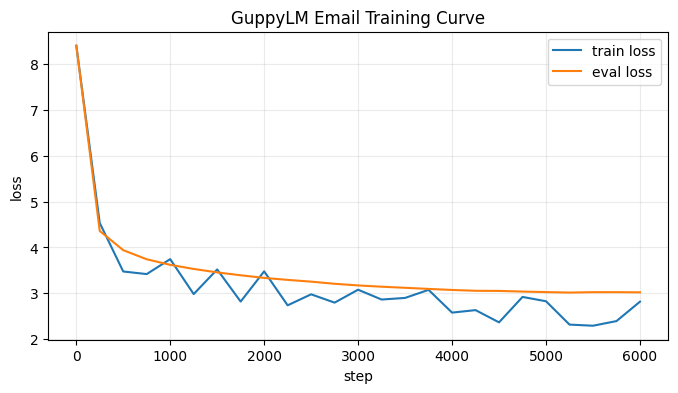

In [26]:
if history:
    steps = [r["step"] for r in history]
    train_losses = [r["train_loss"] for r in history]
    eval_losses = [r["eval_loss"] for r in history]
    plt.figure(figsize=(8, 4))
    plt.plot(steps, train_losses, label="train loss")
    plt.plot(steps, eval_losses, label="eval loss")
    plt.xlabel("step")
    plt.ylabel("loss")
    plt.title("GuppyLM Email Training Curve")
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()
else:
    print("No history yet.")

## 10. Load Best Model and Generate Samples

In [27]:
ckpt_path = CHECKPOINT_DIR / "best_model.pt"
if not ckpt_path.exists():
    raise FileNotFoundError("No best_model.pt found. Run training first.")

ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
best_model = GuppyEmailLM(model_config).to(device)
best_model.load_state_dict(ckpt["model_state_dict"])
best_model.eval()
print(f"loaded checkpoint step={ckpt['step']}, eval_loss={ckpt['eval_loss']:.4f}")

trained_samples = []
for email in sample_emails:
    output = summarize(best_model, email, max_new_tokens=80, temperature=0.7, top_k=40)
    trained_samples.append({"email": email, "output": output})
    print("EMAIL:", email)
    print("SUMMARY:", output)
    print()

final_eval_loss, final_eval_ppl = evaluate_loss(best_model, test_loader, max_batches=train_config.eval_batches)
final_results = {
    "test_loss_sampled": final_eval_loss,
    "test_perplexity_sampled": final_eval_ppl,
    "samples": trained_samples,
    "checkpoint": str(ckpt_path),
}
(EVAL_DIR / "trained_sample_results.json").write_text(json.dumps(final_results, indent=2), encoding="utf-8")
print(json.dumps(final_results, indent=2))

loaded checkpoint step=5250, eval_loss=3.0180
EMAIL: The budget review meeting has moved to Friday at 2pm. Please bring final numbers and confirm attendance.
SUMMARY: hey, the meeting meeting dec 3 at 2pm. all good!

EMAIL: Please send the signed contract by noon tomorrow. Legal needs it before the client call.
SUMMARY: email received, nothing specific to report

EMAIL: Lunch menu for next week is attached. Reply if you have dietary restrictions.
SUMMARY: email received, nothing specific to report

{
  "test_loss_sampled": 2.9207646891474726,
  "test_perplexity_sampled": 18.55547120343378,
  "samples": [
    {
      "email": "The budget review meeting has moved to Friday at 2pm. Please bring final numbers and confirm attendance.",
      "output": "hey, the meeting meeting dec 3 at 2pm. all good!"
    },
    {
      "email": "Please send the signed contract by noon tomorrow. Legal needs it before the client call.",
      "output": "email received, nothing specific to report"
    },
    

In [29]:
from pathlib import Path
import shutil

drive_out = Path("/content/drive/MyDrive/guppylm_email_outputs")
drive_out.mkdir(parents=True, exist_ok=True)

shutil.copy2("/content/checkpoints/best_model.pt", drive_out / "best_model.pt")
print("saved to", drive_out / "best_model.pt")

saved to /content/drive/MyDrive/guppylm_email_outputs/best_model.pt


## 11. Export Package

Creates a compact archive containing model weights, config, tokenizer, and evaluation artifacts. Download this file back into the repo after training.

In [30]:
package_path = WORK_DIR / "guppylm_email_512.tar.gz"
with tarfile.open(package_path, "w:gz") as tar:
    tar.add(CHECKPOINT_DIR / "best_model.pt", arcname="checkpoints/best_model.pt")
    tar.add(CHECKPOINT_DIR / "config.json", arcname="checkpoints/config.json")
    tar.add(DATA_DIR / "tokenizer.json", arcname="data/training/tokenizer.json")
    for name in ["baseline_results.json", "training_history.json", "trained_sample_results.json"]:
        path = EVAL_DIR / name
        if path.exists():
            tar.add(path, arcname=f"evaluation/{name}")

print(f"Package: {package_path} ({package_path.stat().st_size / 1e6:.2f} MB)")
try:
    from google.colab import files
    files.download(str(package_path))
except Exception:
    print("Download manually from the file browser if not running inside Colab.")

Package: /content/guppylm_email_512.tar.gz (33.02 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 12. What should there be

- `checkpoints/best_model.pt`
- `checkpoints/config.json`
- `data/training/tokenizer.json`
- `evaluation/baseline_results.json`
- `evaluation/training_history.json`
- `evaluation/trained_sample_results.json`